In [1]:
import pandas as pd
import os
file_path = r'data\rawData'
txt_file_path = r'data\processedData'
new_path = r'd:\Desktop\PHD\reasearch\biyework\maml'
os.chdir(new_path)
# 检查当前路径是否切换成功
current_path = os.getcwd()
print(current_path)

d:\Desktop\PHD\reasearch\biyework\maml


In [ ]:

all_data_new_fit_csv=r"data\processedData\FLOOR3\all_data_new_fit.csv"
location_vector_csv = r"model\v1\output\location_vector_v3.csv"

df=pd.read_csv(all_data_new_fit_csv)    
df_location = pd.read_csv(location_vector_csv)

# 1. 每个 location_id 在不同 sf 情况下的 average_rssi 和 snr 的均值和方差
location_sf_stats = df.groupby(['location_id', 'sf']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_mean=('rssi_variance', 'mean'),
).reset_index()


# 2. 每个 sf 在不同 location_id 情况下的 average_rssi 和 snr 的均值和方差
sf_location_stats = df.groupby(['sf', 'location_id']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_var_mean=('rssi_variance', 'mean'),
).reset_index()

# 确保 location_id 的数据类型一致
location_sf_stats['location_id'] = location_sf_stats['location_id'].astype(str)
sf_location_stats['location_id'] = sf_location_stats['location_id'].astype(str)
df_location['location_id'] = df_location['location_id'].astype(str)

# 合并 distance_true 信息到 location_sf_stats
location_sf_stats = pd.merge(location_sf_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 合并 distance_true 信息到 sf_location_stats
sf_location_stats = pd.merge(sf_location_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 保存
location_sf_stats.to_csv(r"data\processedData\FLOOR3\location_sf_stats.csv", index=False)
sf_location_stats.to_csv(r"data\processedData\FLOOR3\sf_location_stats.csv", index=False)


tsne数据分布可视化

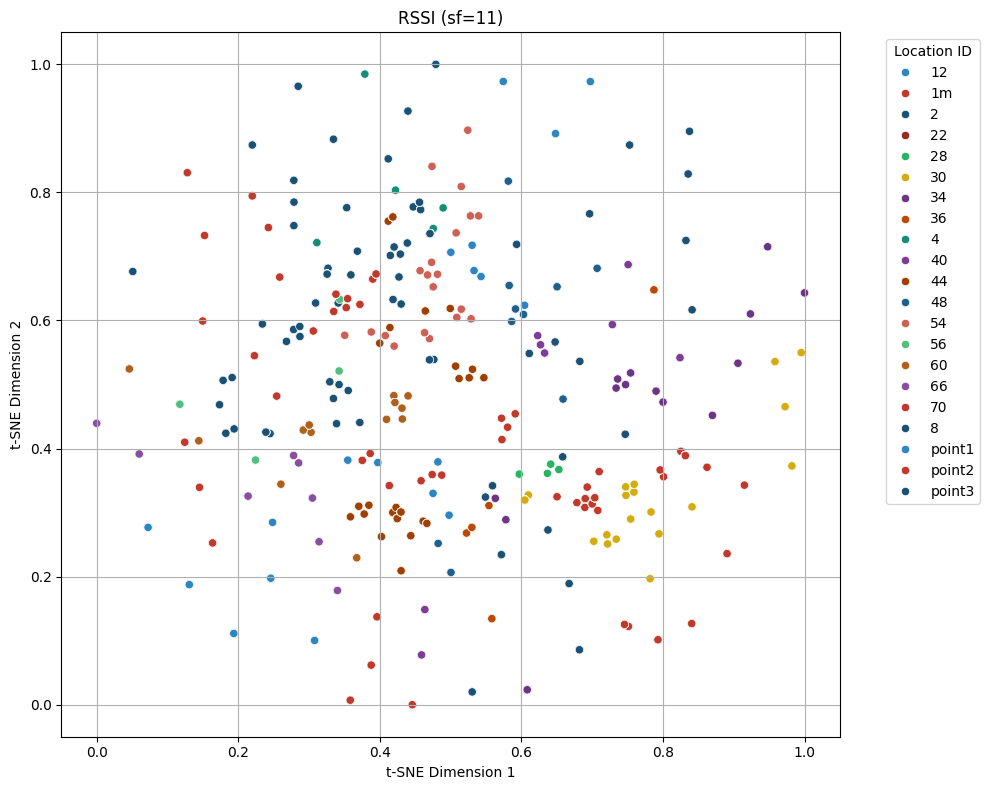

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
# t-sne的输入数据需要是（batch_size,features_dim）的形式
# 1. 读取数据
file_path = r"data\processedData\FLOOR3\all_data_new.csv"   
location_vector_csv = r"model\v1\output\location_vector_v3.csv"  

location_vector = pd.read_csv(location_vector_csv)
data = pd.read_csv(file_path)
sf=11
# 2. 筛选出 sf=sf 的数据
sf_data = data[data['sf']== sf]
# location_list=["point1","370","360","350","336","1m","328","308"]
# 读取 location_vector 数据
sf_data = sf_data[sf_data['location_id'].isin(location_vector['location_id'])]
# sf_data = sf_data[sf_data['location_id'].isin(location_list)]

# features = sf_data[['average_rssi', 'snr','median_rssi','mode_rssi',"rssi_skewness","rssi_kurtosis"]].values
features = sf_data[['average_rssi', 'snr']].values

tsne = TSNE(n_components=2, random_state=42,perplexity=30, max_iter=1000, learning_rate=200)
tsne_results = tsne.fit_transform(features)

# 将降维结果添加到数据框中
sf_data['tsne_1'] = tsne_results[:, 0]
sf_data['tsne_2'] = tsne_results[:, 1]
#   归一化
sf_data['tsne_1'] = (sf_data['tsne_1'] - sf_data['tsne_1'].min()) / (sf_data['tsne_1'].max() - sf_data['tsne_1'].min())
sf_data['tsne_2'] = (sf_data['tsne_2'] - sf_data['tsne_2'].min()) / (sf_data['tsne_2'].max() - sf_data['tsne_2'].min())
# 4. 可视化
plt.figure(figsize=(10, 8))
unique_labels = sf_data['location_id'].unique()
n_labels = len(unique_labels)
# 5. 设置颜色调色板
scientific_colors = [
    '#2E86C1',  # 深蓝（Pantone 7694 C）
    '#C0392B',  # 深红（Pantone 7621 C）
    '#1A5276',  # 普鲁士蓝
    '#922B21',  # 赤陶土色
    '#28B463',  # 翡翠绿
    '#D4AC0D',  # 琥珀金
    '#6C3483',  # 皇室紫
    '#BA4A00',  # 锈橙色
    '#148F77',  # 孔雀石绿
    '#7D3C98',  # 数码紫
    '#A04000',  # 深赭色
    '#1F618D',  # 钢蓝色
    '#CD6155',  # 陶土红
    '#52BE80',  # 薄荷绿
    '#AF601A',  # 皮革棕
    '#884EA0',  # 宝石紫
    '#C0392B',  # 重复色（需要时可扩展）
    '#1A5276'   # 重复色
]
palette = sns.color_palette(scientific_colors * (n_labels//len(scientific_colors)+1))[:n_labels]
sns.scatterplot(
    x='tsne_1', y='tsne_2', 
    hue='location_id', 
    palette=palette, 
    data=sf_data, 
    legend="full"
)
n_labels = len(unique_labels)

plt.title("RSSI (sf={})".format(sf))
plt.grid(True)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Location ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()